<a href="https://colab.research.google.com/github/Vinutha-Reddy/Internship-Projects/blob/main/Project_02_ML_Regression_House_Price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Project Title - House Price Prediction (Regression)**

# **2. Problem Statement**
The real estate industry often needs accurate estimation of property prices based on various
house characteristics. In this task, the goal is to build a Machine Learning regression model
that predicts the price of a house using features such as house size, number of bedrooms,
number of bathrooms, lot size, garage size, neighborhood quality, and the year the house was
built.

# **3. Project Objectives**
The objective of this task is to:
- Understand and explore the housing dataset.
- Perform data preprocessing including handling missing values, duplicates, and outliers.
- Conduct Exploratory Data Analysis (EDA) to identify patterns and relationships in the
data.
- Apply encoding, log transformation, and feature scaling where necessary.
- Train multiple regression algorithms to predict house prices.
- Evaluate and compare model performance using appropriate evaluation metrics.
- Perform cross-validation and hyperparameter tuning to improve model performance.
- Select the best-performing model for final predictions.

# **4. Tools and Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **5. Dataset Loading**

In [ ]:
data = pd.read_csv('house_price_regression_dataset.csv')
data

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


# **6. Preliminary Data Exploration**

In [ ]:
# Dataset Shape
data.shape

(1000, 8)

There are **1000 rows** and **8 columns**

In [ ]:
# Head
data.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [ ]:
# Tail
data.tail()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
995,3261,4,1,1978,2.165110,2,10,701493.997069
996,3179,1,2,1999,2.977123,1,10,683723.160704
997,2606,4,2,1962,4.055067,0,2,572024.023634
998,4723,5,2,1950,1.930921,0,7,964865.298639
999,3268,4,2,1983,3.108790,2,2,742599.253332


In [ ]:
# Dataset Information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [ ]:
# Data Types
data.dtypes

,0
Square_Footage,int64
Num_Bedrooms,int64
Num_Bathrooms,int64
Year_Built,int64
Lot_Size,float64
Garage_Size,int64
Neighborhood_Quality,int64
House_Price,float64


In [ ]:
# Statistical Summary
# Numeric Columns
num_data=data.select_dtypes(include=['int64'])
num_data

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Garage_Size,Neighborhood_Quality
0,1360,2,1,1981,0,5
1,4272,3,3,2016,1,6
2,3592,1,2,2016,0,9
3,966,1,2,1977,1,8
4,4926,2,1,1993,0,8
...,...,...,...,...,...,...
995,3261,4,1,1978,2,10
996,3179,1,2,1999,1,10
997,2606,4,2,1962,0,2
998,4723,5,2,1950,0,7


In [ ]:
# Statistical report of Numerical data
data.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [ ]:
data.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

In [ ]:
# Unique Values
df = data[['Num_Bedrooms','Num_Bathrooms','Garage_Size','Neighborhood_Quality']]
for x in df:
    print(f"{x} --> {df[x].unique()}")
    print()

Num_Bedrooms --> [2 3 1 5 4]

Num_Bathrooms --> [1 3 2]

Garage_Size --> [0 1 2]

Neighborhood_Quality --> [ 5  6  9  8  1  2  4 10  7  3]



In [ ]:
# Value Counts
for x in df:
    print(df[x].value_counts())
    print()

Num_Bedrooms
2    215
5    205
1    201
4    197
3    182
Name: count, dtype: int64

Num_Bathrooms
1    350
2    327
3    323
Name: count, dtype: int64

Garage_Size
2    343
1    336
0    321
Name: count, dtype: int64

Neighborhood_Quality
10    123
5     109
2     105
7     102
6     101
4      99
8      97
1      91
9      88
3      85
Name: count, dtype: int64



# **7. Data Cleaning and Preparation**

**7.1 Duplicate Handling**

In [ ]:
data.duplicated().sum()

np.int64(0)

There are **no duplicate values** in the data.

**7.2 Missing Value Treatment**

In [ ]:
data.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


There are **no missing values** in the data.

# **8. Data Visualization and Analysis**

**8.1 Univariate Analysis**

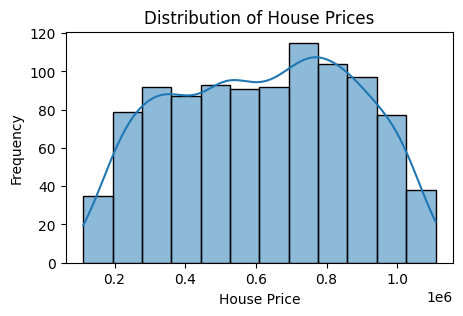

In [ ]:
# Distribution of House Prices
plt.figure(figsize=(5,3))
sns.histplot(data['House_Price'], kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.show()

**Insights**
* Most house prices are concentrated in the mid–high range, showing that many houses fall in this price bracket.
* There are fewer houses at the extreme ends.
* The distribution shows a gradual increase toward higher prices.


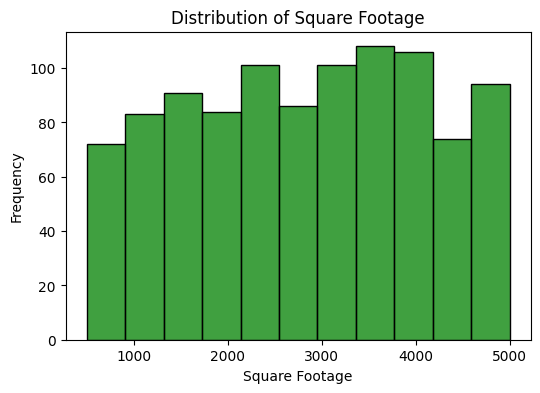

In [ ]:
# Distribution of Square Footage
plt.figure(figsize=(6,4))
sns.histplot(data['Square_Footage'], color='green')
plt.title("Distribution of Square Footage")
plt.xlabel("Square Footage")
plt.ylabel("Frequency")
plt.show()

**Insights**
- Most houses have moderate square footage, indicating average sized homes are common.
- Very large houses exist but are less frequent.
- This shows the dataset mainly contains mid-sized residential properties.

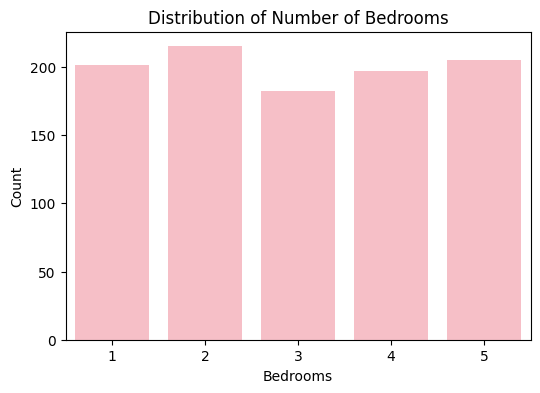

In [ ]:
# Distribution of Number of Bedrooms
plt.figure(figsize=(6,4))
sns.countplot(x=data['Num_Bedrooms'], color='lightpink')
plt.title("Distribution of Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Count")
plt.show()

**Insights**
- Houses with 2 bedrooms have the highest count, indicating that this type of house is the most common in the dataset.
- 3-bedroom houses appear slightly less frequently compared to the other categories.
- The counts for 1, 4, and 5-bedroom houses are relatively similar, showing a fairly balanced distribution among these categories.

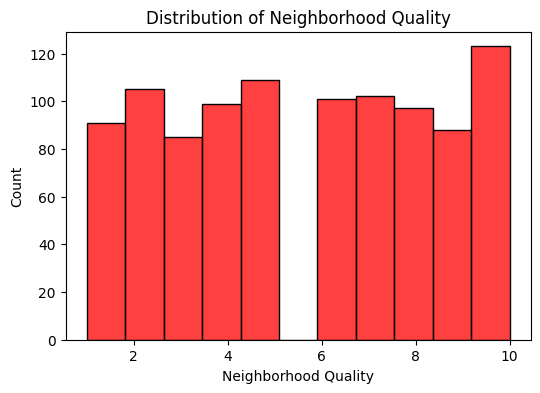

In [ ]:
# Distribution of Neighborhood Quality
plt.figure(figsize=(6,4))
sns.histplot(data['Neighborhood_Quality'], color='red')
plt.title("Distribution of Neighborhood Quality")
plt.xlabel("Neighborhood Quality")
plt.ylabel("Count")
plt.show()

**Insights**
- The neighborhood quality values are spread across the full range from 1 to 10, showing that the dataset includes areas with both low and high quality.
- Most of the values appear to be concentrated between 4 and 9, indicating that many houses are located in average to good quality neighborhoods.

**8.2 Bivariate Analysis**

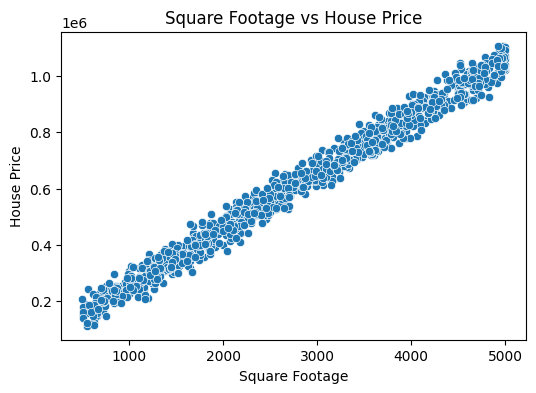

In [ ]:
# Square Footage vs House Price
plt.figure(figsize=(6,4))
sns.scatterplot(x=data['Square_Footage'], y=data['House_Price'])
plt.title("Square Footage vs House Price")
plt.xlabel("Square Footage")
plt.ylabel("House Price")
plt.show()

**Insights**
- There is a clear positive relationship between square footage and house price, meaning larger houses tend to have higher prices.
- As the size of the house increases from around 500 to 5000 square feet, the price also steadily increases.
- The points are closely clustered along an upward trend, indicating a strong correlation between house size and price.

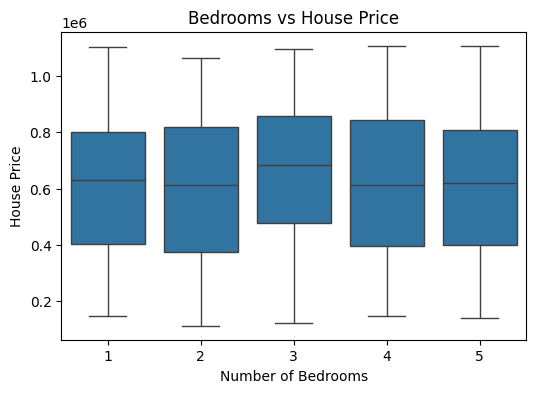

In [ ]:
# Number of Bedrooms vs House Price
plt.figure(figsize=(6,4))
sns.boxplot(x=data['Num_Bedrooms'], y=data['House_Price'])
plt.title("Bedrooms vs House Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("House Price")
plt.show()

**Insights**
- The median house price is somewhat similar across different bedroom categories, showing that price does not increase strictly with the number of bedrooms.
- Houses with 3 and 4 bedrooms tend to have slightly higher median prices compared to 1 or 2 bedroom houses.

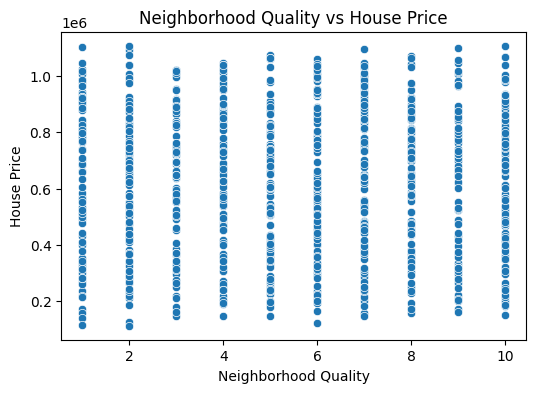

In [ ]:
# Neighborhood Quality vs House Price
plt.figure(figsize=(6,4))
sns.scatterplot(x=data['Neighborhood_Quality'], y=data['House_Price'])
plt.title("Neighborhood Quality vs House Price")
plt.xlabel("Neighborhood Quality")
plt.ylabel("House Price")
plt.show()

**Insights**
- The graph shows that house prices tend to increase when the neighborhood quality rating becomes higher.
- At each neighborhood quality level, the house prices are spread out widely, which means houses in the same quality area can still have different prices.

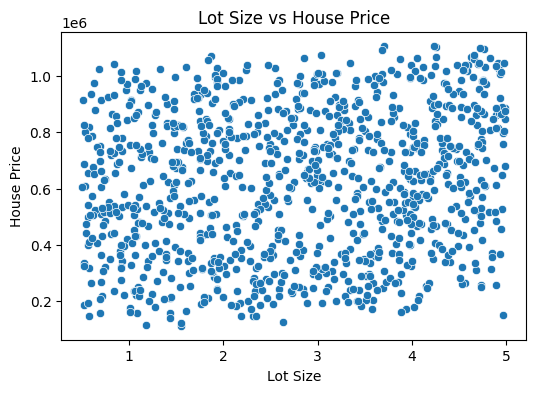

In [ ]:
# Lot Size vs House Price
plt.figure(figsize=(6,4))
sns.scatterplot(x=data['Lot_Size'], y=data['House_Price'])
plt.title("Lot Size vs House Price")
plt.xlabel("Lot Size")
plt.ylabel("House Price")
plt.show()

**Insights**
- The graph shows that as lot size increases, house prices tend to increase slightly.

- There is a wide spread of house prices for both small and large lot sizes, which means lot size alone does not fully determine the house price.

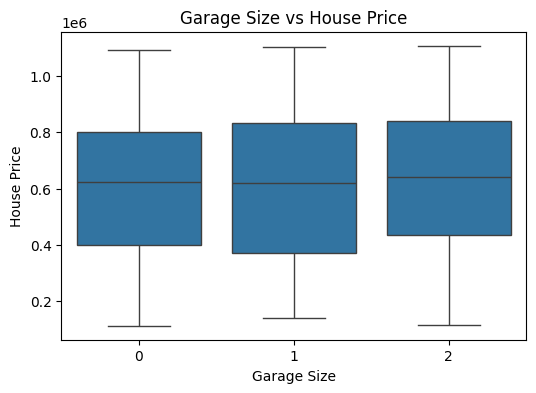

In [ ]:
# Garage Size vs House Price
plt.figure(figsize=(6,4))
sns.boxplot(x=data['Garage_Size'], y=data['House_Price'])
plt.title("Garage Size vs House Price")
plt.xlabel("Garage Size")
plt.ylabel("House Price")
plt.show()

**Insights**
- The graph shows that houses with larger garage sizes tend to have slightly higher median house prices.
- The price range is wide for all garage sizes, which means house price is influenced by other factors as well.
- Houses with garage size 2 appear to have a slightly higher median price compared to garage sizes 0 and 1.

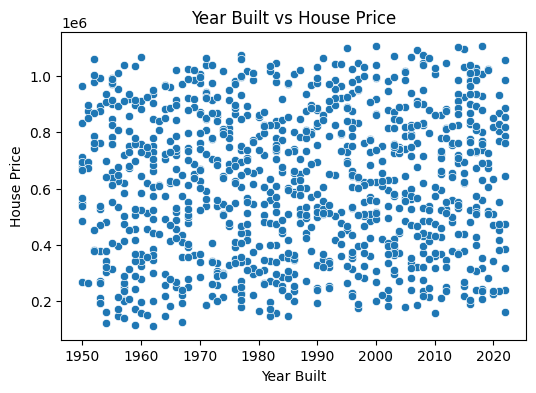

In [ ]:
# Year Built vs House Price
plt.figure(figsize=(6,4))
sns.scatterplot(x=data['Year_Built'], y=data['House_Price'])
plt.title("Year Built vs House Price")
plt.xlabel("Year Built")
plt.ylabel("House Price")
plt.show()

**Insights**
- The graph shows that houses built in different years have a wide range of prices.
- There is no very strong pattern between year built and house price, as both older and newer houses have high and low prices.
- Slightly higher priced houses can be seen more often among the houses built after the year 2000.

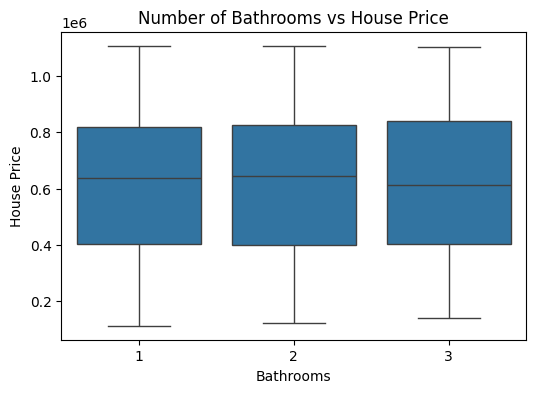

In [ ]:
# Bathrooms vs House Price
plt.figure(figsize=(6,4))
sns.boxplot(x=data['Num_Bathrooms'], y=data['House_Price'])
plt.title("Number of Bathrooms vs House Price")
plt.xlabel("Bathrooms")
plt.ylabel("House Price")
plt.show()

**Insights**
- Houses with more bathrooms generally have higher prices.
- Price ranges increase as the number of bathrooms increases.

**8.3 Multivariate Analysis**

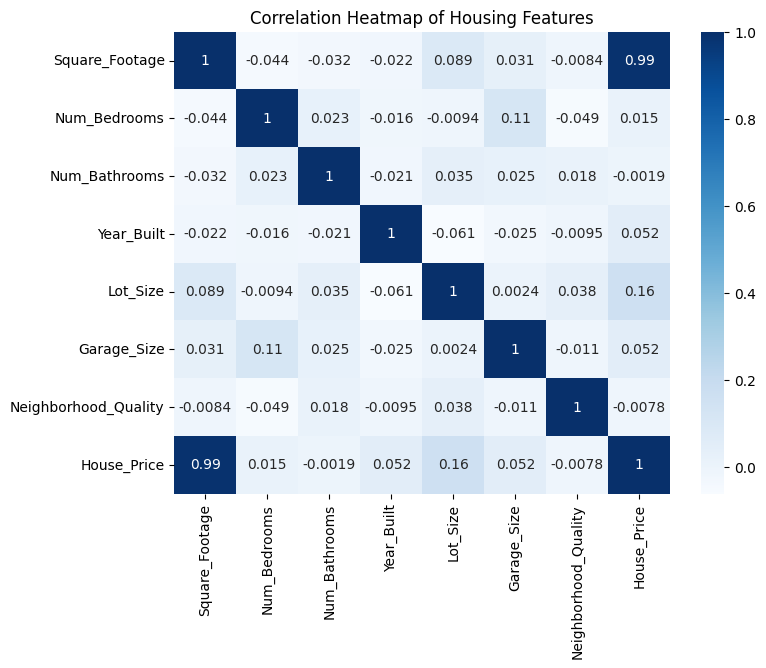

In [ ]:
# Correlation Heatmap of All Variables
plt.figure(figsize=(8,6))
corr = data.corr()
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title("Correlation Heatmap of Housing Features")
plt.show()

**Insights**
- Square_Footage and House_Price show a very strong positive correlation (0.99). This means that as the size of the house increases, the price of the house also increases significantly.
- Lot_Size has a small positive relationship with House_Price (0.16). This suggests that houses with larger land areas tend to have slightly higher prices.
- Most other features like Num_Bedrooms, Num_Bathrooms, and Neighborhood_Quality show very weak correlation with House_Price, indicating they have less direct impact on price in this dataset.

<Figure size 800x600 with 0 Axes>

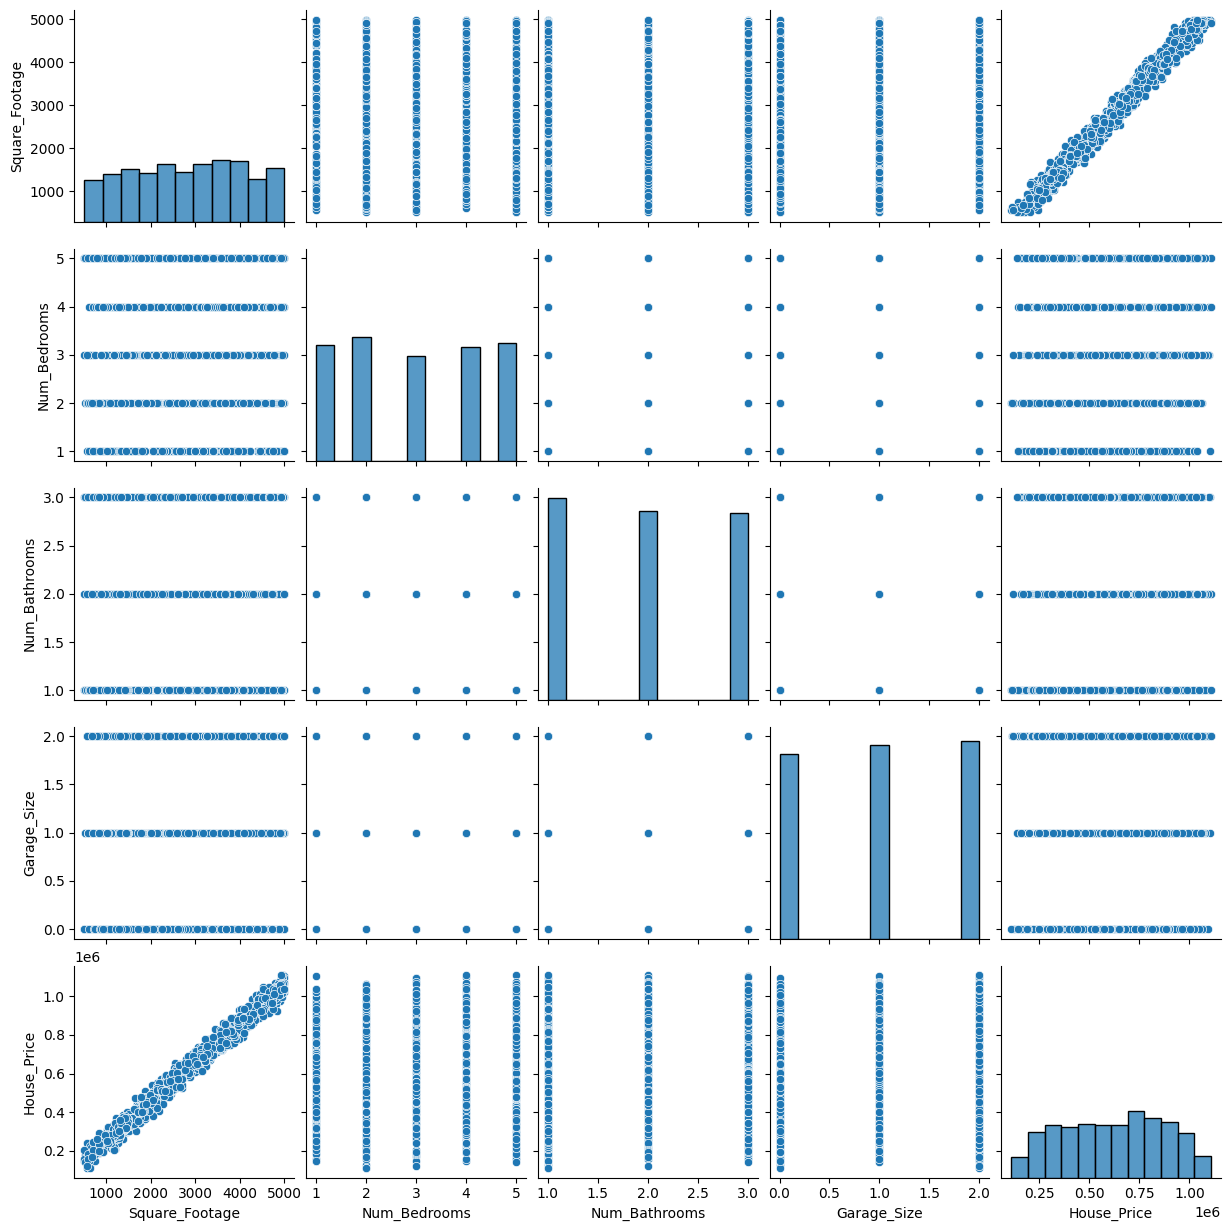

In [ ]:
# Pairplot (Feature Relationships)
plt.figure(figsize=(8,6))
sns.pairplot(data[['Square_Footage','Num_Bedrooms','Num_Bathrooms','Garage_Size','House_Price']])
plt.show()

**Insights**
- The scatter plot between Square_Footage and House_Price shows a clear upward trend. This indicates that houses with larger square footage generally have higher prices.
- Num_Bedrooms and Num_Bathrooms do not show a strong pattern with House_Price. The points are spread out, which suggests these features alone do not strongly affect the price.
- Garage_Size also shows no clear relationship with House_Price. Houses with different garage sizes appear across many different price ranges.

# **9. Detect and Handle Outliers**

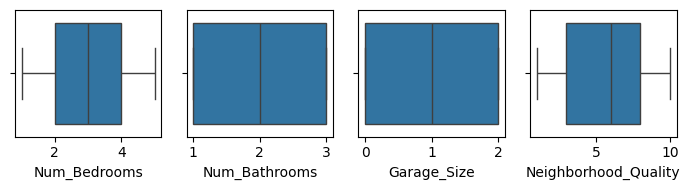

In [ ]:
# Check the direction of outliers in numerical columns
fig,ax = plt.subplots(1,4,figsize=(7,2))
sns.boxplot(data,x='Num_Bedrooms',ax=ax[0])
sns.boxplot(data,x='Num_Bathrooms',ax=ax[1])
sns.boxplot(data,x='Garage_Size',ax=ax[2])
sns.boxplot(data,x='Neighborhood_Quality',ax=ax[3])
plt.tight_layout()

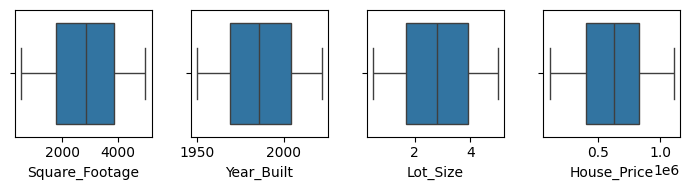

In [ ]:
fig,ax = plt.subplots(1,4,figsize=(7,2))
sns.boxplot(data,x='Square_Footage',ax=ax[0])
sns.boxplot(data,x='Year_Built',ax=ax[1])
sns.boxplot(data,x='Lot_Size',ax=ax[2])
sns.boxplot(data,x='House_Price',ax=ax[3])
plt.tight_layout()

There are **no outliers** in the dataset.

# **10. Encoding**

In [ ]:
data.dtypes

,0
Square_Footage,int64
Num_Bedrooms,int64
Num_Bathrooms,int64
Year_Built,int64
Lot_Size,float64
Garage_Size,int64
Neighborhood_Quality,int64
House_Price,float64


Encoding techniques are not required for this dataset since all input features are already represented as numerical values, and there are no categorical variables that need transformation.

# **10. Scaling and Log Transformation**

**MinMax scalar**

In [ ]:
df1 = data.copy()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

columns_to_scale = [
    'Square_Footage',
    'Num_Bedrooms',
    'Num_Bathrooms',
    'Year_Built',
    'Lot_Size',
    'Garage_Size',
    'Neighborhood_Quality'
]

df1[columns_to_scale] = scaler.fit_transform(df1[columns_to_scale])

In [ ]:
df1

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,0.190614,0.25,0.0,0.430556,0.020873,0.0,0.444444,2.623829e+05
1,0.838301,0.50,1.0,0.916667,0.947295,0.5,0.555556,9.852609e+05
2,0.687055,0.00,0.5,0.916667,0.697880,0.0,0.888889,7.779774e+05
3,0.102980,0.00,0.5,0.375000,0.496205,0.5,0.777778,2.296989e+05
4,0.983763,0.25,0.0,0.597222,0.935263,0.0,0.777778,1.041741e+06
...,...,...,...,...,...,...,...,...
995,0.613434,0.75,0.0,0.388889,0.370056,1.0,1.000000,7.014940e+05
996,0.595196,0.00,0.5,0.680556,0.551178,0.5,1.000000,6.837232e+05
997,0.467749,0.75,0.5,0.166667,0.791616,0.0,0.111111,5.720240e+05
998,0.938612,1.00,0.5,0.000000,0.317820,0.0,0.666667,9.648653e+05


**Transformation**

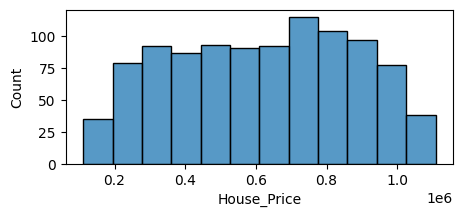

In [ ]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='House_Price')
plt.show()

In [ ]:
data['House_Price'].skew()

np.float64(-0.06395513907654668)

Log transformation was not applied because the house price data is approximately normally distributed and does not exhibit significant skewness.

# **12. Feature Extraction**

In [ ]:
df = data[['Square_Footage','Num_Bedrooms','Num_Bathrooms','Year_Built','Lot_Size','Garage_Size','Neighborhood_Quality']]

<Axes: >

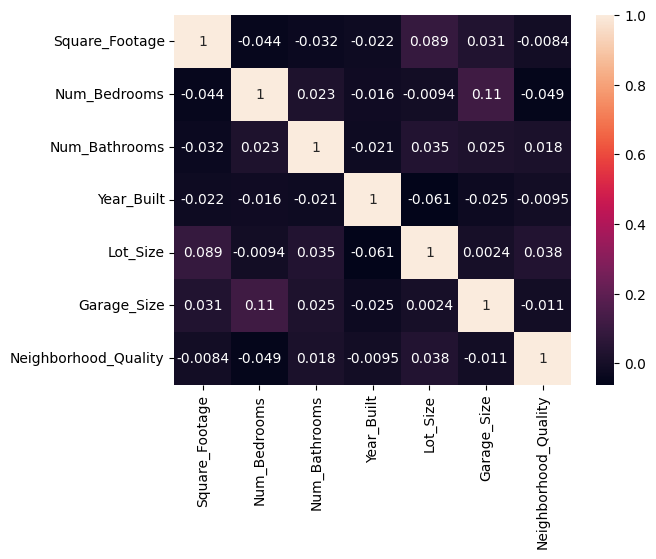

In [ ]:
sns.heatmap(df.corr(),annot=True)

# **13. Train-Test Split**

**Split Data for X and Y**

In [ ]:
x=df1.drop(columns='House_Price')
y=df1.loc[:,'House_Price']

**Split Data for Training and Testing**

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
data.shape

(1000, 8)

In [ ]:
x_train.shape

(800, 7)

In [ ]:
x_test.shape

(200, 7)

In [ ]:
y_train.shape

(800,)

In [ ]:
y_test.shape

(200,)

# **14. Model Building**

**a. Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,r2_score

In [ ]:
# mean square error
mse = mean_squared_error(y_test,y_pred)
mse

101434798.5056357

In [ ]:
# mean absolute error
mae = mean_absolute_error(y_test,y_pred)
mae

8174.583600006607

In [ ]:
# root mean squared error
rmse = np.sqrt(mse)
rmse

np.float64(10071.484424137074)

In [ ]:
# mean absolute percentage error
mape = mean_absolute_percentage_error(y_test,y_pred)
mape

0.016639061459737328

In [ ]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.9984263636823413

In [ ]:
# adjusted r2 score
n = x_test.shape[0]
p = x_test.shape[1]
adj = 1-(1-r2)*(n-1)/(n-p-1)
adj

0.9983689915249266

99.84% better model

**b. KNN Regressor**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=3)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [ ]:
# mean square error
mse = mean_squared_error(y_test,y_pred)
mse

12495678743.553658

In [ ]:
# mean absolute error
mae = mean_absolute_error(y_test,y_pred)
mae

93033.42972390998

In [ ]:
# root mean squared error
rmse = np.sqrt(mse)
rmse

np.float64(111784.07195818936)

In [ ]:
# mean absolute percentage error
mape = mean_absolute_percentage_error(y_test,y_pred)
mape

0.2066113765759448

In [ ]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.8061448913554148

In [ ]:
# adjusted r2 score
adj = 1-(1-r2)*(n-1)/(n-p-1)
adj

0.7990772571860809

80.61% better model

**c. Decision Tree Regressor**

In [ ]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(criterion='squared_error',max_depth=6,max_features='sqrt',min_samples_split=5,min_samples_leaf=3)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# mean squared error
mean_squared_error(y_test,y_pred)

6266527987.974658

In [ ]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

58437.319703688445

In [ ]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(79161.40466145518)

In [ ]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.13374068811172424

In [ ]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.9027825147505606

In [ ]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.8992381272675081

90.27% better model

# **Cross Validation**

**K fold**

In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
model = DecisionTreeRegressor(criterion='squared_error',max_depth=6,max_features='sqrt',min_samples_split=5,min_samples_leaf=3)
kfold = KFold(n_splits=5,shuffle=True,random_state=42)
scores = cross_val_score(model,x_train,y_train,cv=kfold)

In [ ]:
scores

array([0.40454716, 0.84386849, 0.57517238, 0.79488115, 0.85579454])

In [ ]:
print(np.mean(scores))

0.694852744517953


**Stratified K Fold**

In [ ]:
from sklearn.model_selection import StratifiedKFold
model = DecisionTreeRegressor(criterion='squared_error',max_depth=6,max_features='sqrt',min_samples_split=5,min_samples_leaf=3)
sfold = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scores = cross_val_score(model,x_train,y_train)

In [ ]:
scores

array([ 0.2004953 ,  0.80683395,  0.85302782, -0.03174827,  0.92233338])

In [ ]:
print(np.mean(scores))

0.5501884371918929


**d. Random Forest Regressor**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=10,max_depth=6,max_features=5,bootstrap=True,min_samples_split=5,min_samples_leaf=3)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [ ]:
# mean squared error
mean_squared_error(y_test,y_pred)

641852321.3724835

In [ ]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

20287.03255581821

In [ ]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(25334.804545772273)

In [ ]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.04184760979260868

In [ ]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.9900424495501989

In [ ]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.9896794138567166

99% better model

**e. Gradient Boosting Regressor**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
model=GradientBoostingRegressor()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# mean squared error
mean_squared_error(y_test,y_pred)

227154436.12502396

In [ ]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

12372.742401876683

In [ ]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(15071.643444728381)

In [ ]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.025050014283961496

In [ ]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.9964759779122176

In [ ]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.9963474979402672

99.64% better model

**f. XGBOOST Regressor**

In [ ]:
from xgboost import XGBRegressor
model = XGBRegressor()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# mean squared error
mean_squared_error(y_test,y_pred)

307036242.4167654

In [ ]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

14254.423743543553

In [ ]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(17522.449669403115)

In [ ]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.029583541637695006

In [ ]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.9952367097975984

In [ ]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.9950630481756358

99.52% better model

**g. SVM Regressor**

In [ ]:
from sklearn.svm import SVR
model = SVR()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# mean squared error
mean_squared_error(y_test,y_pred)

64536360129.61939

In [ ]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

219480.35073898511

In [ ]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(254040.07583375383)

In [ ]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.5229858166830649

In [ ]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

-0.001202364530021205

In [ ]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

-0.037704534070178264

# **15. Hyperparameter Tuning**

**a.  Linear Regression**

**Grid SearchCV**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
model = LinearRegression()
params = {
    'fit_intercept': [True, False]
}
grid = GridSearchCV(estimator=model, param_grid=params, cv=5)
grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=LinearRegression(),
             param_grid={'fit_intercept': [True, False]})

In [ ]:
print(grid.best_params_)

{'fit_intercept': True}


In [ ]:
model = LinearRegression(fit_intercept=True)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# mean squared error
mean_squared_error(y_test,y_pred)

101434798.5056357

In [ ]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

8174.583600006607

In [ ]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(10071.484424137074)

In [ ]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.016639061459737328

In [ ]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.9984263636823413

In [ ]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.9983689915249266

**Randomized SearchCV**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV
model = LinearRegression()
params = {
    'fit_intercept': [True, False]
}
random = RandomizedSearchCV(estimator=model,
                            param_distributions=params,
                            cv=5,
                            n_iter=2)
random.fit(x_train, y_train)

RandomizedSearchCV(cv=5, estimator=LinearRegression(), n_iter=2,
                   param_distributions={'fit_intercept': [True, False]})

In [ ]:
print(random.best_params_)

{'fit_intercept': True}


In [ ]:
model = LinearRegression(fit_intercept=True)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# mean squared error
mean_squared_error(y_test,y_pred)

101434798.5056357

In [ ]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

8174.583600006607

In [ ]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(10071.484424137074)

In [ ]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.016639061459737328

In [ ]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.9984263636823413

In [ ]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.9983689915249266

**b. KNN Regressor**

**Grid SearchCV**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor()
params = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]   # 1 = Manhattan, 2 = Euclidean
}
grid = GridSearchCV(estimator=model, param_grid=params, cv=5)
grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid={'n_neighbors': [3, 5, 7, 9], 'p': [1, 2],
                         'weights': ['uniform', 'distance']})

In [ ]:
print(grid.best_params_)

{'n_neighbors': 7, 'p': 2, 'weights': 'distance'}


In [ ]:
model = KNeighborsRegressor(n_neighbors= 7, p= 2, weights='distance')
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# mean squared error
mean_squared_error(y_test,y_pred)

9727877304.95927

In [ ]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

80375.84622053035

In [ ]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(98630.00205292135)

In [ ]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.18278108960573278

In [ ]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.8490839312904926

In [ ]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.8435817829521252

**Randomised SearchCV**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor()
params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}
random = RandomizedSearchCV(estimator=model,
                            param_distributions=params,
                            cv=5,
                            n_iter=10)
random.fit(x_train, y_train)

RandomizedSearchCV(cv=5, estimator=KNeighborsRegressor(),
                   param_distributions={'n_neighbors': [3, 5, 7, 9, 11],
                                        'p': [1, 2],
                                        'weights': ['uniform', 'distance']})

In [ ]:
print(random.best_params_)

{'weights': 'distance', 'p': 2, 'n_neighbors': 5}


In [ ]:
model = KNeighborsRegressor(n_neighbors= 5, p= 2, weights='distance')
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# mean squared error
mean_squared_error(y_test,y_pred)

10644749902.286139

In [ ]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

83656.17834499241

In [ ]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(103173.39726056391)

In [ ]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.1905797944113673

In [ ]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.8348597790362794

In [ ]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.8288390418136438

**c. Decision Tree Regressor**

**Grid SearchCV**

In [ ]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
params = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid = GridSearchCV(estimator=model, param_grid=params, cv=5)
grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': [3, 5, 7, 10],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]})

In [ ]:
print(grid.best_params_)

{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [ ]:
model = DecisionTreeRegressor(max_depth =10, min_samples_leaf=4, min_samples_split=2)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# mean squared error
mean_squared_error(y_test,y_pred)

893698587.7033832

In [ ]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

24206.170390306193

In [ ]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(29894.791982942166)

In [ ]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.05110317689622827

In [ ]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.9861353640430195

In [ ]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.9856298825237546

**Randomised SearchCV**

In [ ]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
params = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
random = RandomizedSearchCV(estimator=model,
                            param_distributions=params,
                            cv=5,
                            n_iter=10)
random.fit(x_train, y_train)

RandomizedSearchCV(cv=5, estimator=DecisionTreeRegressor(),
                   param_distributions={'max_depth': [3, 5, 7, 10],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10]})

In [ ]:
print(random.best_params_)

{'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 7}


In [ ]:
model = DecisionTreeRegressor(max_depth =7, min_samples_leaf=4, min_samples_split=10)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# mean squared error
mean_squared_error(y_test,y_pred)

929853416.8899652

In [ ]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

23920.348409203485

In [ ]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(30493.49794447933)

In [ ]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.05118262458870104

In [ ]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.9855744662731718

In [ ]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.9850485353560479

**d. Random Forest Regressor**

**Grid SearchCV**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid = GridSearchCV(estimator=model, param_grid=params, cv=5)
grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [5, 10, 15], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]})

In [ ]:
print(grid.best_params_)

{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
model = RandomForestRegressor(max_depth=15, min_samples_leaf= 1, min_samples_split=2, n_estimators=100)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# mean squared error
mean_squared_error(y_test,y_pred)

383906854.67971075

In [ ]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

15856.167683688525

In [ ]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(19593.54114701349)

In [ ]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.03201103808109927

In [ ]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.994044156660019

In [ ]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.9938270165382489

**Randomised SearchCV**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
random = RandomizedSearchCV(estimator=model,
                            param_distributions=params,
                            cv=5,
                            n_iter=10)
random.fit(x_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(),
                   param_distributions={'max_depth': [5, 10, 15, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]})

In [ ]:
print(random.best_params_)

{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}


In [ ]:
model = RandomForestRegressor(max_depth=10, min_samples_leaf= 1, min_samples_split=2, n_estimators=100)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# mean squared error
mean_squared_error(y_test,y_pred)

383919960.255368

In [ ]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

15921.172133346861

In [ ]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(19593.875580276814)

In [ ]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.032694507375217924

In [ ]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.9940439533431088

In [ ]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.9938268058087429

**e. Gradient Boosting Regressor**

**Grid SearchCV**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
model = GradientBoostingRegressor()
params = {'max_depth':[5,6,7],'n_estimators':[100,200,300],
          'learning_rate':[0.01,0.1,0.2]}
grid = GridSearchCV(estimator=model,param_grid=params,cv=5)
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=GradientBoostingRegressor(),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [5, 6, 7],
                         'n_estimators': [100, 200, 300]})

In [ ]:
print(grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}


In [ ]:
model = GradientBoostingRegressor(learning_rate=0.1,max_depth=5,n_estimators=300)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# mean squared error
mean_squared_error(y_test,y_pred)

229228317.15683156

In [ ]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

12318.294834912847

In [ ]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(15140.287882231023)

In [ ]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.025421354079768307

In [ ]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.996443804195128

In [ ]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.9963141512230754

**Randomised SearchCV**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
model = GradientBoostingRegressor()
params = {'max_depth':[5,6,7],'n_estimators':[100,200,300],
          'learning_rate':[0.01,0.1,0.2]}
random = RandomizedSearchCV(estimator=model,param_distributions=params,cv=5,n_iter=10)
random.fit(x_train,y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingRegressor(),
                   param_distributions={'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [5, 6, 7],
                                        'n_estimators': [100, 200, 300]})

In [ ]:
print(random.best_params_)

{'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1}


In [ ]:
model = GradientBoostingRegressor(n_estimators=300,max_depth=5,learning_rate=0.1)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# mean squared error
mean_squared_error(y_test,y_pred)

229205515.69624397

In [ ]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

12327.324588818681

In [ ]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(15139.534857327815)

In [ ]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.025367391795205006

In [ ]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.9964441579317845

In [ ]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.9963145178563808

**f. XGBOOST Regressor**

**Grid SearchCV**

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
model = XGBRegressor()
params = {'max_depth':[4,5,6],'n_estimators':[10,50,100,200,300],
          'learning_rate':[0.01,0.1,0.2],'reg_alpha':[0.1,0.01,0.2,0.3],
          'reg_lambda':[1,5,8,10]}
grid = GridSearchCV(estimator=model,param_grid=params,cv=5)
grid.fit(x_train,y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [4, 5, 6],
                         'n_estimators': [10, 50, 100, 200, 300],
                         'reg_alpha': [0.1, 0.01, 0.2, 0.3],
                         'reg_lambda': [1, 5, 8, 10]})

In [ ]:
print(grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300, 'reg_alpha': 0.1, 'reg_lambda': 5}


In [ ]:
model = XGBRegressor(learning_rate=0.1,max_depth=4,n_estimators=300,
                     reg_alpha=0.1,reg_lambda=5)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# mean squared error
mean_squared_error(y_test,y_pred)

193537442.9359664

In [ ]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

11268.486442504609

In [ ]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(13911.773536683466)

In [ ]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.02320548619674927

In [ ]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.9969975042735072

In [ ]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.9968880382834788

**Randomised SearchCV**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
model = XGBRegressor()
params = {'max_depth':[4,5,6],'n_estimators':[10,50,100,200,300],
          'learning_rate':[0.01,0.1,0.2],'reg_alpha':[0.1,0.01,0.2,0.3],
          'reg_lambda':[1,5,8,10]}
random = RandomizedSearchCV(estimator=model,param_distributions=params,cv=5,n_iter=10)
random.fit(x_train,y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   param_distributions={'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [4, 5, 6],
                                        'n_estimators': [10, 50, 100, 200, 300],
                                        'reg_alpha': [0.1, 0.01, 0.2, 0.3],
                                        'reg_lambda': [1, 5, 8, 10]})

In [ ]:
print(random.best_params_)

{'reg_lambda': 8, 'reg_alpha': 0.2, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.2}


In [ ]:
model = XGBRegressor(learning_rate=0.2,max_depth=4,n_estimators=200,
                     reg_alpha=0.2,reg_lambda=8)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# mean squared error
mean_squared_error(y_test,y_pred)

212505309.19542572

In [ ]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

11529.020982660924

In [ ]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(14577.561839876575)

In [ ]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.023698168842968804

In [ ]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.9967032411246262

In [ ]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.9965830467906281

**g. SVM Regressor**

**Grid SearchCV**

In [ ]:
from sklearn.model_selection import GridSearchCV
model = SVR()
parameters = {'kernel':['linear','poly','rbf','sigmoid'],
              'gamma':[0.1,0.01,0.001],'C':[1,5,10,15]}
grid = GridSearchCV(estimator=model,param_grid=parameters,cv=5)
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [1, 5, 10, 15], 'gamma': [0.1, 0.01, 0.001],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']})

In [ ]:
print(grid.best_params_)

{'C': 15, 'gamma': 0.1, 'kernel': 'linear'}


In [ ]:
model = SVR(C=15,gamma=0.1,kernel='linear')
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# mean squared error
mean_squared_error(y_test,y_pred)

64138402641.05919

In [ ]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

218801.84962081775

In [ ]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(253255.60732402193)

In [ ]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.5213002085182202

In [ ]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.00497145713777436

In [ ]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

-0.031305625154077754

**Randomised SearchCV**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
model = SVR()
parameters = {'kernel':['linear','poly','rbf','sigmoid'],
              'gamma':[0.1,0.01,0.001],'C':[1,5,10,15]}
random = RandomizedSearchCV(estimator=model,param_distributions=parameters,cv=5,n_iter=10)
random.fit(x_train,y_train)

RandomizedSearchCV(cv=5, estimator=SVR(),
                   param_distributions={'C': [1, 5, 10, 15],
                                        'gamma': [0.1, 0.01, 0.001],
                                        'kernel': ['linear', 'poly', 'rbf',
                                                   'sigmoid']})

In [ ]:
print(random.best_params_)

{'kernel': 'linear', 'gamma': 0.01, 'C': 5}


In [ ]:
model = SVR(C=5,gamma=0.01,kernel='linear')
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# mean squared error
mean_squared_error(y_test,y_pred)

64411406296.51957

In [ ]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

219267.71526556977

In [ ]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(253794.02336642912)

In [ ]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

0.5224560437487817

In [ ]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.0007361407235345618

In [ ]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

-0.035695354145919955

# **16. Compare model performance**

In [ ]:
import pandas as pd

# Your data
data = {
    "Model Name": [
        "Linear Regression",
        "KNN Regressor",
        "Decision Tree Regressor",
        "Random Forest Regressor",
        "Gradient Boosting Regressor",
        "XGBoost Regressor",
        "SVM Regressor"
    ],
    "MSE": [
        101434798.50,
        12495678743.55,
        6266527987.97,
        641852321.37,
        227154436.13,
        307036242.42,
        64536360129.61
    ],
    "MAE": [
        8174.58,
        93033.43,
        58437.32,
        20287.03,
        12372.74,
        14254.42,
        219480.35
    ],
    "RMSE": [
        10071.47,
        111783.20,
        79161.40,
        25334.80,
        15071.64,
        17522.45,
        254040.07
    ],
    "MAPE": [
        0.0166,
        0.2066,
        0.1337,
        0.0418,
        0.0250,
        0.0295,
        0.5229
    ],
    "R2": [
        0.9984,
        0.8061,
        0.9028,
        0.9900,
        0.9964,
        0.9952,
        -0.0012
    ],
    "Adj R2": [
        0.9984,
        0.9983,
        0.8992,
        0.9896,
        0.9963,
        0.9950,
        -0.0377
    ]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Display table
print(df)

                    Model Name           MSE        MAE       RMSE    MAPE  \
0            Linear Regression  1.014348e+08    8174.58   10071.47  0.0166   
1                KNN Regressor  1.249568e+10   93033.43  111783.20  0.2066   
2      Decision Tree Regressor  6.266528e+09   58437.32   79161.40  0.1337   
3      Random Forest Regressor  6.418523e+08   20287.03   25334.80  0.0418   
4  Gradient Boosting Regressor  2.271544e+08   12372.74   15071.64  0.0250   
5            XGBoost Regressor  3.070362e+08   14254.42   17522.45  0.0295   
6                SVM Regressor  6.453636e+10  219480.35  254040.07  0.5229   

       R2  Adj R2  
0  0.9984  0.9984  
1  0.8061  0.9983  
2  0.9028  0.8992  
3  0.9900  0.9896  
4  0.9964  0.9963  
5  0.9952  0.9950  
6 -0.0012 -0.0377  


# **17. Select the Best Performing Model**

Best Performing Model: Linear Regression

Reason:
It has the highest R² score and lowest error values (MSE, MAE, RMSE), indicating the model fits the data more accurately compared to other models.